

################ VAR2 ################


DEGREE ANALYSIS
Degree  1 | Train MSE=32.2661 | CV MSE=32.4669 | Train R²=0.2801 | CV R²=0.2729
Degree  2 | Train MSE=20.9290 | CV MSE=21.6138 | Train R²=0.5330 | CV R²=0.5121
Degree  3 | Train MSE=11.4265 | CV MSE=12.0279 | Train R²=0.7451 | CV R²=0.7298
Degree  4 | Train MSE=3.5358 | CV MSE=3.8957 | Train R²=0.9211 | CV R²=0.9126
Degree  5 | Train MSE=1.3649 | CV MSE=1.5553 | Train R²=0.9695 | CV R²=0.9652
Degree  6 | Train MSE=0.4614 | CV MSE=0.5706 | Train R²=0.9897 | CV R²=0.9872
Degree  7 | Train MSE=0.2504 | CV MSE=0.3421 | Train R²=0.9944 | CV R²=0.9923
Degree  8 | Train MSE=0.1735 | CV MSE=0.2741 | Train R²=0.9961 | CV R²=0.9938
Degree  9 | Train MSE=0.1518 | CV MSE=0.3022 | Train R²=0.9966 | CV R²=0.9932
Degree 10 | Train MSE=0.1384 | CV MSE=0.3653 | Train R²=0.9969 | CV R²=0.9917
Degree 11 | Train MSE=0.1203 | CV MSE=0.5420 | Train R²=0.9973 | CV R²=0.9878
Degree 12 | Train MSE=0.1051 | CV MSE=1.1422 | Train R²=0.9977 | CV R²=0.9740

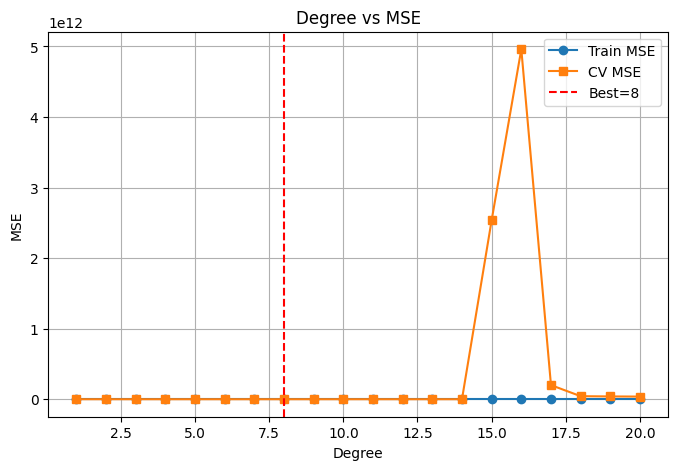

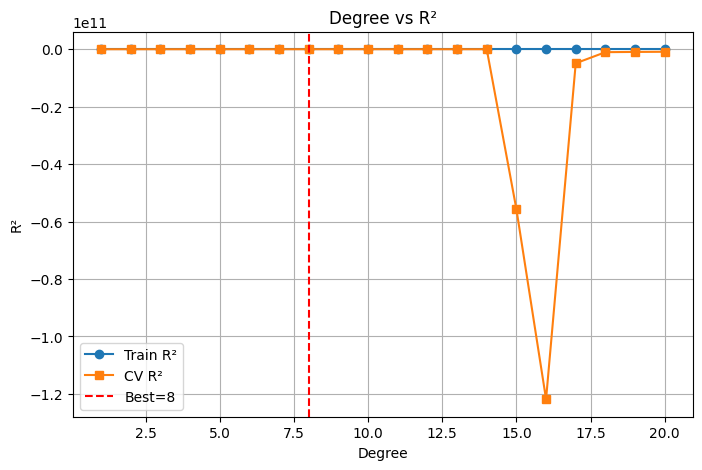


Saved: MS2026012_pred_var2.csv


################ VAR1 ################


DEGREE ANALYSIS
Degree  1 | Train MSE=8.9057 | CV MSE=9.0419 | Train R²=0.1137 | CV R²=0.0997
Degree  2 | Train MSE=2.6174 | CV MSE=2.8269 | Train R²=0.7395 | CV R²=0.7167
Degree  3 | Train MSE=0.7136 | CV MSE=0.9172 | Train R²=0.9290 | CV R²=0.9070
Degree  4 | Train MSE=0.3553 | CV MSE=0.7526 | Train R²=0.9646 | CV R²=0.9241
Degree  5 | Train MSE=0.1236 | CV MSE=1.3080 | Train R²=0.9877 | CV R²=0.8684
Degree  6 | Train MSE=0.0171 | CV MSE=102.5237 | Train R²=0.9983 | CV R²=-9.2617
Degree  7 | Train MSE=0.0000 | CV MSE=8.1679 | Train R²=1.0000 | CV R²=0.1524
Degree  8 | Train MSE=0.0000 | CV MSE=4.1929 | Train R²=1.0000 | CV R²=0.5647
Degree  9 | Train MSE=0.0000 | CV MSE=3.7194 | Train R²=1.0000 | CV R²=0.6166
Degree 10 | Train MSE=0.0000 | CV MSE=3.1673 | Train R²=1.0000 | CV R²=0.6751


FULL RESULTS TABLE
   Degree     Train_MSE      CV_MSE  Train_R2     CV_R2
0       1  8.905653e+00    9.041902  0.113747  0.

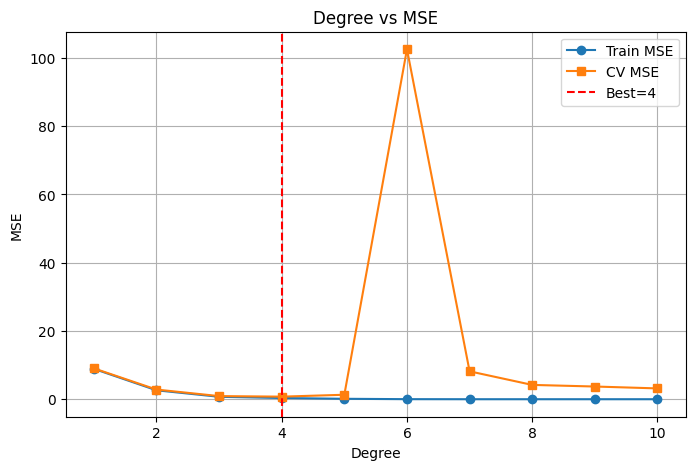

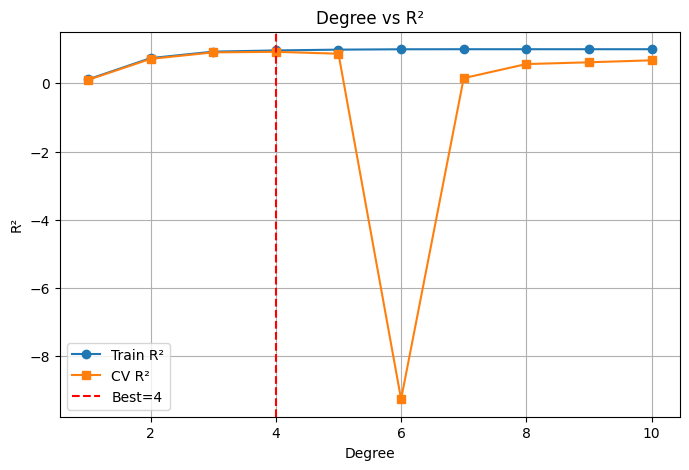


Saved: MS2026012_pred_var1.csv


SUMMARY
VAR2 BEST DEGREE : 8
VAR1 BEST DEGREE : 4

Generated Files:
MS2026012_pred_var2.csv
MS2026012_pred_var1.csv
var2_degree_analysis.csv
var1_degree_analysis.csv


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

# ============================================================
# LOAD FILES
# ============================================================

train_var2 = pd.read_csv("MS2026012_train_var2.csv")
test_var2 = pd.read_csv("MS2026012_test_var2.csv")

train_var1 = pd.read_csv("MS2026012_train_var1.csv")
test_var1 = pd.read_csv("MS2026012_test_var1.csv")

# ============================================================
# FUNCTION
# ============================================================

def polynomial_analysis(
    train_df,
    test_df,
    max_degree,
    output_file
):

    X = train_df.drop(columns=["y"])
    y = train_df["y"]

    results = []

    best_degree = None
    best_cv_mse = np.inf

    kfold = KFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    print("\n")
    print("="*80)
    print("DEGREE ANALYSIS")
    print("="*80)

    for degree in range(1, max_degree + 1):

        model = Pipeline([
            ("poly", PolynomialFeatures(
                degree=degree,
                include_bias=False
            )),
            ("lr", LinearRegression())
        ])

        model.fit(X, y)

        train_pred = model.predict(X)

        train_mse = mean_squared_error(y, train_pred)
        train_r2 = r2_score(y, train_pred)

        cv_mse = -cross_val_score(
            model,
            X,
            y,
            cv=kfold,
            scoring="neg_mean_squared_error"
        ).mean()

        cv_r2 = cross_val_score(
            model,
            X,
            y,
            cv=kfold,
            scoring="r2"
        ).mean()

        results.append([
            degree,
            train_mse,
            cv_mse,
            train_r2,
            cv_r2
        ])

        print(
            f"Degree {degree:2d} | "
            f"Train MSE={train_mse:.4f} | "
            f"CV MSE={cv_mse:.4f} | "
            f"Train R²={train_r2:.4f} | "
            f"CV R²={cv_r2:.4f}"
        )

        if cv_mse < best_cv_mse:
            best_cv_mse = cv_mse
            best_degree = degree

    results_df = pd.DataFrame(
        results,
        columns=[
            "Degree",
            "Train_MSE",
            "CV_MSE",
            "Train_R2",
            "CV_R2"
        ]
    )

    print("\n")
    print("FULL RESULTS TABLE")
    print(results_df)

    print("\nBEST DEGREE =", best_degree)
    print("BEST CV MSE =", best_cv_mse)

    # ============================================================
    # PLOT 1 : DEGREE vs TRAIN/CV MSE
    # ============================================================

    plt.figure(figsize=(8,5))

    plt.plot(
        results_df["Degree"],
        results_df["Train_MSE"],
        marker='o',
        label="Train MSE"
    )

    plt.plot(
        results_df["Degree"],
        results_df["CV_MSE"],
        marker='s',
        label="CV MSE"
    )

    plt.axvline(
        best_degree,
        color='red',
        linestyle='--',
        label=f'Best={best_degree}'
    )

    plt.xlabel("Degree")
    plt.ylabel("MSE")
    plt.title("Degree vs MSE")
    plt.legend()
    plt.grid(True)

    plt.show()

    # ============================================================
    # PLOT 2 : DEGREE vs TRAIN/CV R²
    # ============================================================

    plt.figure(figsize=(8,5))

    plt.plot(
        results_df["Degree"],
        results_df["Train_R2"],
        marker='o',
        label="Train R²"
    )

    plt.plot(
        results_df["Degree"],
        results_df["CV_R2"],
        marker='s',
        label="CV R²"
    )

    plt.axvline(
        best_degree,
        color='red',
        linestyle='--',
        label=f'Best={best_degree}'
    )

    plt.xlabel("Degree")
    plt.ylabel("R²")
    plt.title("Degree vs R²")
    plt.legend()
    plt.grid(True)

    plt.show()

    # ============================================================
    # FINAL MODEL
    # ============================================================

    final_model = Pipeline([
        (
            "poly",
            PolynomialFeatures(
                degree=best_degree,
                include_bias=False
            )
        ),
        (
            "lr",
            LinearRegression()
        )
    ])

    final_model.fit(X, y)

    predictions = final_model.predict(test_df)

    pred_df = pd.DataFrame({
        "y": predictions
    })

    pred_df.to_csv(
        output_file,
        index=False
    )

    print("\nSaved:", output_file)

    return results_df, best_degree


# ============================================================
# VAR2 FIRST
# ============================================================

print("\n\n################ VAR2 ################")

var2_table, best_deg_var2 = polynomial_analysis(
    train_var2,
    test_var2,
    max_degree=20,
    output_file="MS2026012_pred_var2.csv"
)

# ============================================================
# VAR1 NEXT
# ============================================================

print("\n\n################ VAR1 ################")

var1_table, best_deg_var1 = polynomial_analysis(
    train_var1,
    test_var1,
    max_degree=10,
    output_file="MS2026012_pred_var1.csv"
)

# ============================================================
# SAVE TABLES
# ============================================================

var2_table.to_csv(
    "var2_degree_analysis.csv",
    index=False
)

var1_table.to_csv(
    "var1_degree_analysis.csv",
    index=False
)

print("\n")
print("="*80)
print("SUMMARY")
print("="*80)

print("VAR2 BEST DEGREE :", best_deg_var2)
print("VAR1 BEST DEGREE :", best_deg_var1)

print("\nGenerated Files:")
print("MS2026012_pred_var2.csv")
print("MS2026012_pred_var1.csv")
print("var2_degree_analysis.csv")
print("var1_degree_analysis.csv")